In [33]:
# --- Librerías ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (10,4)

# --- Rutas ---
RUTA = Path(r"C:\Users\Vìctor\OneDrive\Desktop\ESP_Project")
FILE = "df_con_eventos_hibridos.xlsx"

# --- Carga SIN renombrar columnas ---
df = pd.read_excel(RUTA/FILE, engine="openpyxl")

# Conversión de tipos sin cambiar nombres
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

def to_num_series(s: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(s):  # ya es numérico
        return s
    s2 = (
        s.astype(str)
         .str.replace(" ", "", regex=False)
         .str.replace("\u00A0","", regex=False)
         .str.replace(".", "", regex=False)     # miles
         .str.replace(",", ".", regex=False)    # coma → punto
    )
    return pd.to_numeric(s2, errors="coerce")

num_cols = [
    "prueba_de_produccion_petróleo_a_24_horas_bbld",
    "prueba_de_producción_agua_a_24_horas_bbld",
    "prueba_pozooil_24__prueba_pozowater_24",
    "prueba_de_producción_gas_a_24_horas_mcfd",
    "bsw_pct","gravedad_api_del_petroleo","salinidad_ppm_pu",
    "presion_de_intake_psi","frecuencia_bomba_hz","amperaje_bomba_amp",
    "presion_de_tubing_psi","presion_de_casing_psi",
    "temperatura_de_la_bomba_deg_f","etapas_de_la_bomba",
    "delta_1","delta_3","slope_7","slope_14",
]
for c in num_cols:
    if c in df.columns:
        df[c] = to_num_series(df[c])

# Orden lógico
orden_cols = [c for c in ["name_", "date"] if c in df.columns]
if orden_cols:
    df = df.sort_values(orden_cols).reset_index(drop=True)

print("✅ Dataset listo:", df.shape)


✅ Dataset listo: (16161, 24)


Definir régimen operativo (pozo + tipo de bomba normalizado)

In [34]:
# Normalización ligera de 'tipo_de_bomba' sin alterar la columna original:
def norm_bomba(s):
    if pd.isna(s): 
        return np.nan
    s = str(s).strip().replace(" ", "")
    # a|a → a ; a/a → a (elimina duplicados triviales)
    for sep in ["|","/"]:
        if sep in s:
            parts = [p for p in s.split(sep) if p]
            parts = list(dict.fromkeys(parts))  # únicos preservando orden
            if len(parts) == 1:
                s = parts[0]
            else:
                s = sep.join(parts)
    return s

df["bomba_norm"] = df["tipo_de_bomba"].apply(norm_bomba)
df["regimen_id"] = df["name_"].astype(str) + "||" + df["bomba_norm"].astype(str)


Construir el envelope por régimen (percentiles con mínimos de observación)

In [35]:
V_QTOT = "prueba_pozooil_24__prueba_pozowater_24"
V_HZ   = "frecuencia_bomba_hz"           if "frecuencia_bomba_hz" in df.columns else None
V_AMP  = "amperaje_bomba_amp"            if "amperaje_bomba_amp"  in df.columns else None
V_PINT = "presion_de_intake_psi"         if "presion_de_intake_psi" in df.columns else None

def pct_series(s, p, min_obs=8):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) < min_obs:
        return np.nan
    return float(np.nanpercentile(s, p))

grp = df.groupby(["name_", "regimen_id"], dropna=False)

limits = grp.agg(**{
    "Q20":   (V_QTOT, lambda s: pct_series(s, 20)) if V_QTOT else (V_QTOT, lambda s: np.nan),
    "Q80":   (V_QTOT, lambda s: pct_series(s, 80)) if V_QTOT else (V_QTOT, lambda s: np.nan),
    "Hz10":  (V_HZ,   lambda s: pct_series(s, 10)) if V_HZ   else (V_HZ,   lambda s: np.nan),
    "Hz90":  (V_HZ,   lambda s: pct_series(s, 90)) if V_HZ   else (V_HZ,   lambda s: np.nan),
    "Amp95": (V_AMP,  lambda s: pct_series(s, 95)) if V_AMP  else (V_AMP,  lambda s: np.nan),
    "Pint10":(V_PINT, lambda s: pct_series(s, 10)) if V_PINT else (V_PINT, lambda s: np.nan),
}).reset_index()

# Métricas de apoyo por régimen (para confiabilidad)
stats_reg = grp.agg(
    n_valid_qtot=(V_QTOT, lambda s: s.dropna().shape[0]) if V_QTOT else (V_QTOT, lambda s: 0),
    n_valid_hz  =(V_HZ,   lambda s: s.dropna().shape[0]) if V_HZ   else (V_HZ,   lambda s: 0),
    n_valid_amp =(V_AMP,  lambda s: s.dropna().shape[0]) if V_AMP  else (V_AMP,  lambda s: 0),
    n_valid_pint=(V_PINT, lambda s: s.dropna().shape[0]) if V_PINT else (V_PINT, lambda s: 0),
).reset_index()

# Merge de límites y stats → df_env (sin perder ninguna columna)
df_env = df.merge(limits, on=["name_", "regimen_id"], how="left")
df_env = df_env.merge(stats_reg, on=["name_", "regimen_id"], how="left")


Evaluación por fila (tolerante a nulos) y confiabilidad

In [36]:
def count_signals_row(row):
    k = 0
    if pd.notna(row.get("Q20")) and pd.notna(row.get("Q80")) and pd.notna(row.get(V_QTOT)): k += 1
    if V_HZ and pd.notna(row.get("Hz10")) and pd.notna(row.get("Hz90")) and pd.notna(row.get(V_HZ)): k += 1
    if V_AMP and pd.notna(row.get("Amp95")) and pd.notna(row.get(V_AMP)): k += 1
    if V_PINT and pd.notna(row.get("Pint10")) and pd.notna(row.get(V_PINT)): k += 1
    return k

df_env["n_vars_env"] = df_env.apply(count_signals_row, axis=1)

def in_envelope(row):
    checks = []

    # Q_total en [Q20, Q80]
    if pd.notna(row.get("Q20")) and pd.notna(row.get("Q80")) and pd.notna(row.get(V_QTOT)):
        checks.append((row[V_QTOT] >= row["Q20"]) and (row[V_QTOT] <= row["Q80"]))

    # Hz en [Hz10, Hz90]
    if V_HZ and pd.notna(row.get("Hz10")) and pd.notna(row.get("Hz90")) and pd.notna(row.get(V_HZ)):
        checks.append((row[V_HZ] >= row["Hz10"]) and (row[V_HZ] <= row["Hz90"]))

    # Amp ≤ Amp95
    if V_AMP and pd.notna(row.get("Amp95")) and pd.notna(row.get(V_AMP)):
        checks.append(row[V_AMP] <= row["Amp95"])

    # Pint ≥ Pint10
    if V_PINT and pd.notna(row.get("Pint10")) and pd.notna(row.get(V_PINT)):
        checks.append(row[V_PINT] >= row["Pint10"])

    if len(checks) == 0:
        return np.nan  # indeterminado si no hay señales
    return all(checks) # AND conservador

df_env["envelope_ok"] = df_env.apply(in_envelope, axis=1)

def fila_confiabilidad(row):
    # tamaño histórico del régimen
    nreg = (row.get("n_valid_qtot") or 0) + (row.get("n_valid_hz") or 0) + (row.get("n_valid_amp") or 0) + (row.get("n_valid_pint") or 0)
    k = row.get("n_vars_env") or 0
    # reglas simples (ajustables)
    if (nreg >= 30) and (k >= 3): return "alta"
    if (nreg >= 16) and (k >= 2): return "media"
    if (nreg >= 8)  and (k >= 1): return "baja"
    return "indeterminado"

df_env["confiabilidad_envelope"] = df_env.apply(fila_confiabilidad, axis=1)

def env_label(x):
    if pd.isna(x): return "indeterminado"
    return "dentro" if bool(x) else "fuera"

df_env["env_label"] = df_env["envelope_ok"].apply(env_label)

print("✅ Envelope evaluado por fila (sin renombrar columnas).")


✅ Envelope evaluado por fila (sin renombrar columnas).


Diagnóstico combinado (evento vs envelope)

In [37]:
def diagnostico_fila(row):
    ev = row.get("evento_hibrido")
    env = row.get("env_label")

    if pd.isna(ev) or pd.isna(env): 
        return "insuficiente/indeterminado"

    # 0=normal, 1=caída, 2=reacondicionamiento (según tu lógica previa)
    if ev == 1 and env == "fuera":
        return "caída + fuera de envelope (alta sospecha)"
    if ev == 1 and env == "dentro":
        return "caída pero dentro de envelope (posible ajuste operativo)"
    if ev == 2 and env == "fuera":
        return "reacondicionamiento + fuera por arriba (coherente con pico)"
    if ev == 2 and env == "dentro":
        return "reacondicionamiento leve dentro de envelope"
    if ev == 0 and env == "fuera":
        return "normal por slope, fuera de envelope (revisar parámetros)"
    if ev == 0 and env == "dentro":
        return "operación normal y en envelope"

    return "caso mixto/indefinido"

df_env["diagnostico_envelope"] = df_env.apply(diagnostico_fila, axis=1)


Visualizaciones rápidas

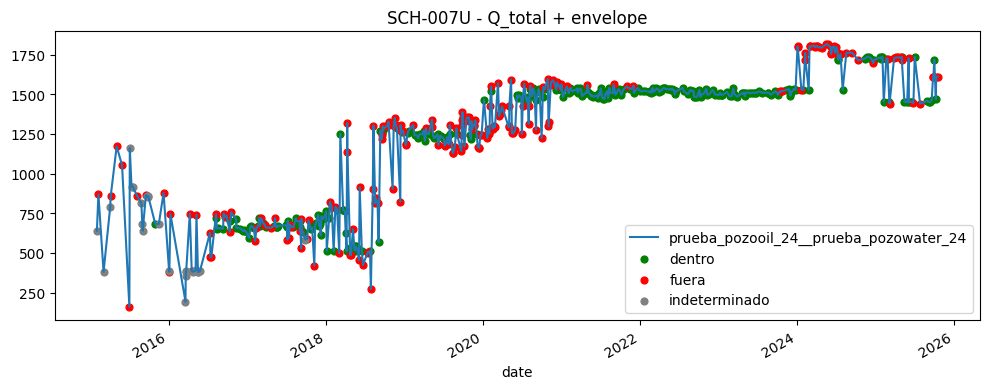

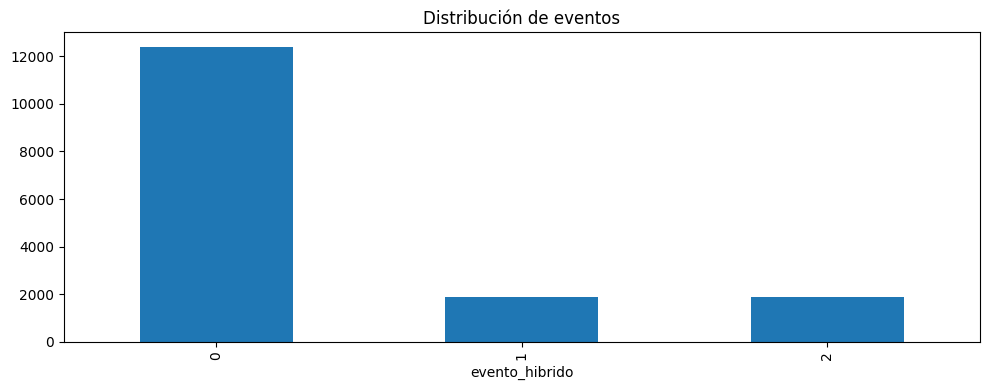

In [38]:
# Línea de Q_total con puntos coloreados por envelope
if "date" in df_env.columns:
    pozo_demo = df_env["name_"].dropna().unique()[0]
    g = df_env[df_env["name_"]==pozo_demo].sort_values("date")

    ax = g.plot(x="date", y=V_QTOT, kind="line", title=f"{pozo_demo} - Q_total + envelope")
    for lbl, color in [("dentro","green"),("fuera","red"),("indeterminado","gray")]:
        gg = g[g["env_label"]==lbl]
        ax.scatter(gg["date"], gg[V_QTOT], s=24, label=lbl, color=color)
    ax.legend(); plt.tight_layout(); plt.show()

# Barras por etiqueta
if "evento_hibrido" in df_env.columns:
    df_env["evento_hibrido"].value_counts(dropna=False).sort_index().plot(kind="bar", title="Distribución de eventos")
    plt.tight_layout(); plt.show()


In [40]:
df.head(20)

,name_,date,prueba_de_produccion_petróleo_a_24_horas_bbld,prueba_de_producción_agua_a_24_horas_bbld,prueba_pozooil_24__prueba_pozowater_24,prueba_de_producción_gas_a_24_horas_mcfd,bsw_pct,gravedad_api_del_petroleo,salinidad_ppm_pu,presion_de_intake_psi,...,etapas_de_la_bomba,campo,delta_1,delta_3,slope_7,slope_14,evento_hibrido,Unnamed: 23,bomba_norm,regimen_id
0,SCH-007U,2015-02-02,204.37,435.73,640.10,14.00,68.07,22.40,NaN,NaN,...,NaN,SACHA NORTE 1,NaN,NaN,NaN,NaN,0,NaN,D725N,SCH-007U||D725N
1,SCH-007U,2015-02-09,216.90,652.63,869.53,14.00,75.05,22.40,NaN,NaN,...,NaN,SACHA NORTE 1,229.43,NaN,NaN,NaN,2,NaN,NaN,SCH-007U||nan
2,SCH-007U,2015-03-05,99.29,281.49,380.78,14.00,73.92,22.40,NaN,NaN,...,NaN,SACHA NORTE 1,-488.75,NaN,-129.66,NaN,1,NaN,TD450,SCH-007U||TD450
3,SCH-007U,2015-04-05,205.33,585.15,790.48,14.00,74.02,22.40,NaN,NaN,...,NaN,SACHA NORTE 1,409.70,150.38,-3.76,NaN,2,NaN,TD450,SCH-007U||TD450
4,SCH-007U,2015-04-07,214.01,642.02,856.03,14.00,75.00,22.40,NaN,NaN,...,NaN,SACHA NORTE 1,65.55,-13.50,35.28,35.28,0,NaN,NaN,SCH-007U||nan
5,SCH-007U,2015-05-05,304.62,867.60,"1,172.22",14.00,74.01,22.40,NaN,NaN,...,NaN,SACHA NORTE 1,316.19,791.44,86.57,86.57,2,NaN,NaN,SCH-007U||nan
6,SCH-007U,2015-05-30,273.78,777.95,"1,051.72",14.00,73.97,22.40,NaN,NaN,...,NaN,SACHA NORTE 1,-120.50,261.24,82.70,82.70,1,NaN,NaN,SCH-007U||nan
7,SCH-007U,2015-07-03,51.09,108.93,160.02,14.00,68.07,22.40,NaN,NaN,...,NaN,SACHA NORTE 1,-891.70,-696.01,-14.46,-0.12,1,NaN,NaN,SCH-007U||nan
8,SCH-007U,2015-07-05,301.73,857.96,"1,159.69",14.00,73.98,22.40,NaN,NaN,...,NaN,SACHA NORTE 1,999.67,-12.53,45.41,27.89,2,NaN,P18SSD,SCH-007U||P18SSD
9,SCH-007U,2015-07-13,229.43,688.30,917.73,14.00,75.00,22.40,NaN,NaN,...,NaN,SACHA NORTE 1,-241.96,-133.99,-0.83,27.43,1,NaN,P8SSD,SCH-007U||P8SSD


In [41]:


COL_POZO  = "name_"
COL_FECHA = "date"

# variables a vigilar en el envelope (ajusta las que tengas disponibles)
vars_env = [
    "prueba_pozooil_24__prueba_pozowater_24",   # Q_total
    "prueba_de_producción_gas_a_24_horas_mcfd", # Q_gas
    "presion_de_intake_psi",                    # P_intake (si hay)
    "frecuencia_bomba_hz"                       # Hz
]

# --- 1A. percentiles por pozo ---
q = (
    df.groupby(COL_POZO)[vars_env]
      .quantile([0.20, 0.50, 0.80])            # Q20/Q50/Q80
      .unstack()                                # columnas multinivel
      .rename(columns={0.2:"Q20", 0.5:"Q50", 0.8:"Q80"})
)

# ordenar columnas (opcional)
q = q.reindex(columns=pd.MultiIndex.from_product([vars_env, ["Q20","Q50","Q80"]]))
q.head(10)


prueba_pozooil_24__prueba_pozowater_24                    \
                                             Q20      Q50      Q80   
name_                                                                
SCH-007U                                  715.00 1,401.00 1,532.00   
SCH-018UI                                 552.00   893.00 1,380.00   
SCH-050UI                               1,977.00 2,053.00 2,684.80   
SCH-083HI                               1,064.00 1,158.00 1,177.00   
SCH-087BT                                 306.00   511.00 1,170.00   
SCH-088T                                  449.00   499.00 1,207.00   
SCH-106HS                                 922.00 1,390.00 2,373.00   
SCH-123UI                                 570.40 1,091.00 1,216.00   
SCH-124UI                                 251.00   417.00   876.60   
SCH-127HS                                 752.00 1,400.00 1,518.00   

          prueba_de_producción_gas_a_24_horas_mcfd                \
                                               Q20    Q50    Q80   
name_                                                              
SCH-007U                                     28.00 101.73 106.35   
SCH-018UI                                     9.44 111.62 220.00   
SCH-050UI                                    30.00  42.39  59.00   
SCH-083HI                                     1.12   1.21   3.00   
SCH-087BT                                    25.05  31.00  33.00   
SCH-088T                                     59.25 134.67 179.76   
SCH-106HS                                    29.00  52.40  61.16   
SCH-123UI                                    73.47 127.18 152.68   
SCH-124UI                                     2.00  48.72  58.75   
SCH-127HS                                    50.65  54.96  74.00   

          presion_de_intake_psi                   frecuencia_bomba_hz        \
                            Q20      Q50      Q80                 Q20   Q50   
name_                                                                         
SCH-007U                 853.60 1,054.50 1,381.00               60.00 63.70   
SCH-018UI                631.00   768.00   856.00               53.00 78.50   
SCH-050UI              1,359.00 1,733.00 1,912.00               54.00 54.00   
SCH-083HI              1,893.00 1,990.99 2,000.00               46.00 47.00   
SCH-087BT                382.00   425.00   641.00               58.00 59.00   
SCH-088T                 341.00   403.50   592.20               59.50 65.50   
SCH-106HS                890.00 1,094.49 1,272.00               54.00 60.00   
SCH-123UI                355.00   408.00   584.00               55.00 61.00   
SCH-124UI                240.40   657.00   729.00               49.00 50.00   
SCH-127HS              1,040.00 1,188.50 1,805.20               60.00 63.70   

                  
             Q80  
name_             
SCH-007U   64.00  
SCH-018UI 139.00  
SCH-050UI 137.00  
SCH-083HI  50.00  
SCH-087BT  61.00  
SCH-088T   71.00  
SCH-106HS  62.00  
SCH-123UI  62.00  
SCH-124UI  59.00  
SCH-127HS  64.50

catálogo de rangos operativos por pozo

In [46]:
from pathlib import Path

RUTA = r"C:\Users\Vìctor\OneDrive\Desktop\ESP_Project"  # ya la tienes
out_path = Path(RUTA) / "rangos_operativos_por_pozo.xlsx"
q.to_excel(out_path)
print("✅ Guardado en:", out_path)



✅ Guardado en: C:\Users\Vìctor\OneDrive\Desktop\ESP_Project\rangos_operativos_por_pozo.xlsx


Añadir columnas de envelope (dentro / fuera / indeterminado) por variable

In [43]:
# helper: mapea Q20/Q80 a cada fila según pozo
for v in vars_env:
    df[f"{v}__Q20"] = df[COL_POZO].map(q[(v,"Q20")])
    df[f"{v}__Q80"] = df[COL_POZO].map(q[(v,"Q80")])

def flag_envelope(row, v):
    x  = row[v]
    lo = row[f"{v}__Q20"]
    hi = row[f"{v}__Q80"]
    if pd.isna(x) or pd.isna(lo) or pd.isna(hi):
        return np.nan
    if x < lo:
        return -1
    if x > hi:
        return 1
    return 0

for v in vars_env:
    df[f"env_{v}"] = df.apply(flag_envelope, axis=1, v=v)


Indicador “envelope_ok” por fila (combinando variables)

In [44]:
env_cols = [f"env_{v}" for v in vars_env]

def combine_envelope(row):
    vals = row[env_cols].dropna().values
    if len(vals) == 0:
        return np.nan           # indeterminado
    return int(np.all(vals == 0))  # 1 si todas 0, sino 0

df["envelope_ok"] = df.apply(combine_envelope, axis=1)


Tabla de rangos + conteos por pozo

In [49]:
# --- 1) Copia de los rangos y aplanado de columnas (MultiIndex -> plano) ---
rangos_resumen = q.copy()  # q viene de groupby(COL_POZO).quantile([.2,.5,.8])
rangos_flat = rangos_resumen.copy()
rangos_flat.columns = [f"{var}__{p}" for (var, p) in rangos_flat.columns]  # ej: 'prueba_pozooil_24__prueba_pozowater_24__Q20'

# --- 2) Conteos de cumplimiento del envelope por pozo ---
ok_counts = (
    df.groupby(COL_POZO)["envelope_ok"]
      .value_counts(dropna=False)
      .unstack(fill_value=0)
      .rename(columns={0: "fueradelsobre", 1: "dentrodelSobre", np.nan: "indeterminado"})
)

# Garantiza que las tres columnas existan aunque falte alguna categoría en un pozo
for c in ["dentrodelSobre", "fueradelsobre", "indeterminado"]:
    if c not in ok_counts.columns:
        ok_counts[c] = 0
ok_counts = ok_counts[["dentrodelSobre", "fueradelsobre", "indeterminado"]]

# --- 3) Join por índice (pozo) ---
resumen_pozo = rangos_flat.join(ok_counts, how="left")

# --- 4) Porcentajes de cumplimiento (útil para comparar pozos) ---
tot = resumen_pozo[["dentrodelSobre", "fueradelsobre", "indeterminado"]].sum(axis=1).replace(0, np.nan)
resumen_pozo["pct_dentro"] = (resumen_pozo["dentrodelSobre"] / tot * 100).round(2)
resumen_pozo["pct_fuera"]  = (resumen_pozo["fueradelsobre"]   / tot * 100).round(2)
resumen_pozo["pct_indet"]  = (resumen_pozo["indeterminado"]   / tot * 100).round(2)

# --- 5) Exporta ---
out_file = out_dir / "resumen_operativo_y_cumplimiento.xlsx"
resumen_pozo.to_excel(out_file)
print("✅ Archivo generado:", out_file)

# --- 6) Vista rápida ---
resumen_pozo.head(10)


✅ Archivo generado: C:\Users\Vìctor\OneDrive\Desktop\ESP_Project\salidas_rangos\resumen_operativo_y_cumplimiento.xlsx


,prueba_pozooil_24__prueba_pozowater_24__Q20,prueba_pozooil_24__prueba_pozowater_24__Q50,prueba_pozooil_24__prueba_pozowater_24__Q80,prueba_de_producción_gas_a_24_horas_mcfd__Q20,prueba_de_producción_gas_a_24_horas_mcfd__Q50,prueba_de_producción_gas_a_24_horas_mcfd__Q80,presion_de_intake_psi__Q20,presion_de_intake_psi__Q50,presion_de_intake_psi__Q80,frecuencia_bomba_hz__Q20,frecuencia_bomba_hz__Q50,frecuencia_bomba_hz__Q80,dentrodelSobre,fueradelsobre,indeterminado,pct_dentro,pct_fuera,pct_indet
name_,,,,,,,,,,,,,,,,,,
SCH-007U,715.00,"1,401.00","1,532.00",28.00,101.73,106.35,853.60,"1,054.50","1,381.00",60.00,63.70,64.00,70,461,0,13.18,86.82,0.00
SCH-018UI,552.00,893.00,"1,380.00",9.44,111.62,220.00,631.00,768.00,856.00,53.00,78.50,139.00,148,488,0,23.27,76.73,0.00
SCH-050UI,"1,977.00","2,053.00","2,684.80",30.00,42.39,59.00,"1,359.00","1,733.00","1,912.00",54.00,54.00,137.00,270,400,0,40.30,59.70,0.00
SCH-083HI,"1,064.00","1,158.00","1,177.00",1.12,1.21,3.00,"1,893.00","1,990.99","2,000.00",46.00,47.00,50.00,201,398,0,33.56,66.44,0.00
SCH-087BT,306.00,511.00,"1,170.00",25.05,31.00,33.00,382.00,425.00,641.00,58.00,59.00,61.00,159,467,0,25.40,74.60,0.00
SCH-088T,449.00,499.00,"1,207.00",59.25,134.67,179.76,341.00,403.50,592.20,59.50,65.50,71.00,128,453,0,22.03,77.97,0.00
SCH-106HS,922.00,"1,390.00","2,373.00",29.00,52.40,61.16,890.00,"1,094.49","1,272.00",54.00,60.00,62.00,140,456,0,23.49,76.51,0.00
SCH-123UI,570.40,"1,091.00","1,216.00",73.47,127.18,152.68,355.00,408.00,584.00,55.00,61.00,62.00,119,235,0,33.62,66.38,0.00
SCH-124UI,251.00,417.00,876.60,2.00,48.72,58.75,240.40,657.00,729.00,49.00,50.00,59.00,299,275,0,52.09,47.91,0.00


In [50]:
def color_env(flag):
    if pd.isna(flag): return "gray"
    return {0:"green", 1:"red", -1:"red"}.get(flag, "gray")

df["env_color_QTOT"] = df[f"env_{vars_env[0]}"].map(color_env)


In [51]:
df.head()

,name_,date,prueba_de_produccion_petróleo_a_24_horas_bbld,prueba_de_producción_agua_a_24_horas_bbld,prueba_pozooil_24__prueba_pozowater_24,prueba_de_producción_gas_a_24_horas_mcfd,bsw_pct,gravedad_api_del_petroleo,salinidad_ppm_pu,presion_de_intake_psi,...,presion_de_intake_psi__Q20,presion_de_intake_psi__Q80,frecuencia_bomba_hz__Q20,frecuencia_bomba_hz__Q80,env_prueba_pozooil_24__prueba_pozowater_24,env_prueba_de_producción_gas_a_24_horas_mcfd,env_presion_de_intake_psi,env_frecuencia_bomba_hz,envelope_ok,env_color_QTOT
0,SCH-007U,2015-02-02,204.37,435.73,640.10,14.00,68.07,22.40,NaN,NaN,...,853.60,"1,381.00",60.00,64.00,-1,-1,NaN,NaN,0,red
1,SCH-007U,2015-02-09,216.90,652.63,869.53,14.00,75.05,22.40,NaN,NaN,...,853.60,"1,381.00",60.00,64.00,0,-1,NaN,NaN,0,green
2,SCH-007U,2015-03-05,99.29,281.49,380.78,14.00,73.92,22.40,NaN,NaN,...,853.60,"1,381.00",60.00,64.00,-1,-1,NaN,NaN,0,red
3,SCH-007U,2015-04-05,205.33,585.15,790.48,14.00,74.02,22.40,NaN,NaN,...,853.60,"1,381.00",60.00,64.00,0,-1,NaN,NaN,0,green
4,SCH-007U,2015-04-07,214.01,642.02,856.03,14.00,75.00,22.40,NaN,NaN,...,853.60,"1,381.00",60.00,64.00,0,-1,NaN,NaN,0,green


Validacion por filas del metodo aplicado 

In [52]:
cols_env = [c for c in df.columns if c.startswith("env_") and c not in ("envelope_ok","env_color_QTOT")]

def recomputa_ok(row):
    vals = [row[c] for c in cols_env if pd.notna(row[c])]
    if len(vals) == 0:
        return np.nan   # indeterminado
    return int(all(v == 0 for v in vals))

# ¿coincide?
df["ok_check"] = df.apply(recomputa_ok, axis=1)
print("Coincidencias:", (df["ok_check"].fillna(-1).eq(df["envelope_ok"].fillna(-1))).mean())
df.loc[:10, ["name_","date","envelope_ok","ok_check"] + cols_env].head(10)


Coincidencias: 1.0


,name_,date,envelope_ok,ok_check,env_prueba_pozooil_24__prueba_pozowater_24,env_prueba_de_producción_gas_a_24_horas_mcfd,env_presion_de_intake_psi,env_frecuencia_bomba_hz
0,SCH-007U,2015-02-02,0,0,-1,-1,NaN,NaN
1,SCH-007U,2015-02-09,0,0,0,-1,NaN,NaN
2,SCH-007U,2015-03-05,0,0,-1,-1,NaN,NaN
3,SCH-007U,2015-04-05,0,0,0,-1,NaN,NaN
4,SCH-007U,2015-04-07,0,0,0,-1,NaN,NaN
5,SCH-007U,2015-05-05,0,0,0,-1,NaN,NaN
6,SCH-007U,2015-05-30,0,0,0,-1,NaN,NaN
7,SCH-007U,2015-07-03,0,0,-1,-1,NaN,NaN
8,SCH-007U,2015-07-05,0,0,0,-1,NaN,NaN
9,SCH-007U,2015-07-13,0,0,0,-1,NaN,NaN


Opción A — Cambiar la regla de decisión (votación)

En vez de exigir que todas las señales disponibles estén dentro, pedimos ≥2 señales dentro o, si solo hay una señal disponible, no decidas.

In [53]:
env_cols = [c for c in df.columns if c.startswith("env_") and c not in ("envelope_ok","env_color_QTOT")]

def combine_envelope_voto(row, min_ok=2):
    vals = [row[c] for c in env_cols if pd.notna(row[c])]
    if len(vals) == 0:
        return np.nan           # indet
    if len(vals) == 1:
        return np.nan           # con 1 señal no decido
    ok = sum(v==0 for v in vals)
    return int(ok >= min_ok)

df["envelope_ok_voto"] = df.apply(combine_envelope_voto, axis=1)


Opción B — Regla condicionada para gas (gating)

En operación BES, gas alto es verdaderamente problemático cuando coincide con otros síntomas (baja P_intake o Hz altos). Penaliza gas solo si hay una de estas condiciones:

In [54]:
def combine_envelope_gated(row):
    checks = []

    # Q_total
    if pd.notna(row["env_prueba_pozooil_24__prueba_pozowater_24"]):
        checks.append(row["env_prueba_pozooil_24__prueba_pozowater_24"] == 0)

    # Hz
    hz_ok = pd.isna(row.get("env_frecuencia_bomba_hz")) or (row["env_frecuencia_bomba_hz"] == 0)
    if pd.notna(row.get("env_frecuencia_bomba_hz")):
        checks.append(hz_ok)

    # Intake
    pint_ok = pd.isna(row.get("env_presion_de_intake_psi")) or (row["env_presion_de_intake_psi"] == 0)
    if pd.notna(row.get("env_presion_de_intake_psi")):
        checks.append(pint_ok)

    # GAS: solo penaliza si gas está fuera **y** (Hz no ok o Intake no ok)
    if pd.notna(row.get("env_prueba_de_producción_gas_a_24_horas_mcfd")):
        gas_out = (row["env_prueba_de_producción_gas_a_24_horas_mcfd"] != 0)
        if gas_out and (not hz_ok or not pint_ok):
            checks.append(False)   # castiga
        else:
            checks.append(True)    # no castiga gas por sí solo
    # si ninguna señal disponible:
    if len(checks)==0: return np.nan
    return int(all(checks))

df["envelope_ok_gated"] = df.apply(combine_envelope_gated, axis=1)


Opción C — Redefinir el envelope de gas (solo cota superior)

Para gas suele interesar “no exceder” más que “estar dentro de [Q20–Q80]”. Usa solo un límite superior (p. ej. P90), y no castigues por debajo:

In [55]:
# construir P90 de gas por pozo
gas_p90 = df.groupby("name_")["prueba_de_producción_gas_a_24_horas_mcfd"].quantile(0.90)
df["gas_P90"] = df["name_"].map(gas_p90)

def env_gas_upper_only(row):
    x = row["prueba_de_producción_gas_a_24_horas_mcfd"]
    p90 = row["gas_P90"]
    if pd.isna(x) or pd.isna(p90): return np.nan
    return 0 if x <= p90 else -1

df["env_gas_upper"] = df.apply(env_gas_upper_only, axis=1)

# y rehaces el 'envelope_ok' usando 'env_gas_upper' en lugar del antiguo env_gas


In [56]:
print(pd.crosstab(df["evento_hibrido"], df["envelope_ok"],        dropna=False))
print(pd.crosstab(df["evento_hibrido"], df["envelope_ok_voto"],   dropna=False))
print(pd.crosstab(df["evento_hibrido"], df["envelope_ok_gated"],  dropna=False))


envelope_ok        0     1
evento_hibrido            
0               8536  3856
1               1532   352
2               1507   378
envelope_ok_voto     0     1
evento_hibrido              
0                 2895  9497
1                  625  1259
2                  467  1418
envelope_ok_gated     0     1
evento_hibrido               
0                  7182  5210
1                  1378   506
2                  1357   528


Para operación real :
Nos quedaremos con gated como núcleo, pero añádiremos dos ajustes para reducir falsos positivos en normales:

Persistencia (histeresis): exigir ≥2 medidas consecutivas “fuera” para marcar la fila como anómala efectiva.

Esto típicamente bajara  los FP en normales sin perder mucha sensibilidad.

Banda de caudal un poco más ancha (robustez): pasar de Q20–Q80 a Q15–Q85 (solo para Q_total).

Suele bajar FP en normales (operación diaria) y mantener bien las caídas/reaconds.

Mantén gas como cota superior (P90/95) y gating con Hz/Intake.

Con esos dos ajustes, esperaría una matriz más parecida a:

Normal (0): mayoría dentro.

Caída (1) y Reacond. (2): mayoría fuera, pero no por “ruido” de una sola lectura.

Abrir banda de caudal y mantener gas-gating

In [57]:
# Recalcula percentiles de caudal con Q15–Q85
q_alt = (
    df.groupby("name_")["prueba_pozooil_24__prueba_pozowater_24"]
      .quantile([0.15, 0.85]).unstack().rename(columns={0.15:"Q15", 0.85:"Q85"})
)
df["QTOT_Q15"] = df["name_"].map(q_alt["Q15"])
df["QTOT_Q85"] = df["name_"].map(q_alt["Q85"])

def env_qtot_15_85(row):
    x, lo, hi = row["prueba_pozooil_24__prueba_pozowater_24"], row["QTOT_Q15"], row["QTOT_Q85"]
    if pd.isna(x) or pd.isna(lo) or pd.isna(hi): return np.nan
    return 0 if (lo <= x <= hi) else -1

df["env_qtot_15_85"] = df.apply(env_qtot_15_85, axis=1)

# Gas solo cota superior (P90 o P95, elige uno)
gasp = df.groupby("name_")["prueba_de_producción_gas_a_24_horas_mcfd"].quantile(0.90)
df["gas_P90"] = df["name_"].map(gasp)

def env_gas_upper(row):
    x, p = row["prueba_de_producción_gas_a_24_horas_mcfd"], row["gas_P90"]
    if pd.isna(x) or pd.isna(p): return np.nan
    return 0 if x <= p else -1

df["env_gas_upper"] = df.apply(env_gas_upper, axis=1)

# Mantén tus env de Hz e Intake como antes (Q10–Q90 y Pint10)


Reglas “gated” (gas penaliza solo si hay síntoma en Hz o Intake) + caudal 15–85

In [58]:
def envelope_ok_gated_v2(row):
    checks = []

    # Caudal con banda más ancha:
    if pd.notna(row.get("env_qtot_15_85")):
        checks.append(row["env_qtot_15_85"] == 0)

    # Hz e Intake (si existen en tu DF)
    hz_ok   = pd.isna(row.get("env_frecuencia_bomba_hz")) or (row.get("env_frecuencia_bomba_hz")==0)
    pint_ok = pd.isna(row.get("env_presion_de_intake_psi")) or (row.get("env_presion_de_intake_psi")==0)

    if pd.notna(row.get("env_frecuencia_bomba_hz")):
        checks.append(hz_ok)
    if pd.notna(row.get("env_presion_de_intake_psi")):
        checks.append(pint_ok)

    # Gas con gating:
    if pd.notna(row.get("env_gas_upper")):
        gas_out = (row["env_gas_upper"] != 0)
        if gas_out and (not hz_ok or not pint_ok):
            checks.append(False)   # penaliza solo si coincide con Hz/Intake malo
        else:
            checks.append(True)

    if len(checks)==0: return np.nan
    return int(all(checks))

df["envelope_ok_gated_v2"] = df.apply(envelope_ok_gated_v2, axis=1)


Persistencia (≥2 fuera consecutivos por pozo)

In [59]:
df = df.sort_values(["name_","date"])
key = "envelope_ok_gated_v2"

# Marcamos “fuera” como 1 para contar rachas
df["fuera_flag"] = (df[key]==0).astype("Int64")  # NaN queda NaN

def persistencia_min2(s):
    # devuelve una serie booleana: True si la fila está en una racha de >=2 “fuera”
    out = pd.Series(False, index=s.index)
    run = 0
    for i, val in enumerate(s):
        if pd.isna(val) or val==0:
            run += 1
        else:
            run = 0
        out.iloc[i] = (run >= 2) if not pd.isna(val) else False
    return out

df["anomalía_persistente"] = (
    df.groupby("name_")["fuera_flag"]
      .transform(persistencia_min2)
      .astype(int)  # 1 si cumple persistencia, 0 si no
)


In [60]:
pd.crosstab(df["evento_hibrido"], df["anomalía_persistente"])


anomalía_persistente,0,1
evento_hibrido,,
0,7399,4993
1,1579,305
2,1580,305


Parámetros del método

In [84]:
PARAMS = {
    "q_low":   0.10,   # percentil inferior para Q_total (envelope)
    "q_high":  0.90,   # percentil superior para Q_total (envelope)
    "gas_high":0.90,   # percentil superior para gas (gate)
    "slope_k": 1.2,    # |slope_7 - mean| > k*std por pozo
    "d1_p":    80,     # percentil de |delta_1| por pozo (shock)
    "persist_n": 3,    # racha mínima de alarmas consecutivas
    "refractory_k": 2  # silencio tras un disparo persistente
}


Librerías + columnas base (sin renombrar tu dataset)

In [85]:
import numpy as np
import pandas as pd

# Dataset: usa 'df' ya cargado (o lee tu archivo si lo necesitas)
# RUTA = r"C:\Users\Vìctor\OneDrive\Desktop\ESP_Project"
# df = pd.read_excel(Path(RUTA)/"df_con_eventos_hibridos.xlsx")

COL_POZO   = "name_"
COL_FECHA  = "date"
COL_QTOT   = "prueba_pozooil_24__prueba_pozowater_24"
COL_QGAS   = "prueba_de_producción_gas_a_24_horas_mcfd"
COL_HZ     = "frecuencia_bomba_hz"
COL_PINT   = "presion_de_intake_psi"
COL_EVENTO = "evento_hibrido"        # (0,1,2)
COL_REG    = "regimen_id"            # ej. SCH-007U||D725N


Tipos y orden temporal

In [86]:
df[COL_FECHA] = pd.to_datetime(df[COL_FECHA], errors="coerce")
df = df.sort_values([COL_POZO, COL_FECHA], na_position="last")

Estadística por pozo (para confirmar tendencia)

In [87]:
stats_pozo = (
    df.groupby(COL_POZO)
      .agg(
          slope7_mean=("slope_7", "mean"),
          slope7_std =("slope_7", "std"),
          d1_p       =("delta_1", lambda s: np.nanpercentile(np.abs(s.dropna()), PARAMS["d1_p"]))
      )
)


Percentiles por pozo × régimen (sobre operativo)

In [88]:
def quant_by_regimen(s, q):
    s = s.dropna()
    return np.nan if s.empty else np.nanpercentile(s, 100*q)

q_by_reg = (
    df.groupby([COL_POZO, COL_REG], dropna=True).agg(
        qtot_lo = (COL_QTOT,  lambda s: quant_by_regimen(s, PARAMS["q_low"])),
        qtot_hi = (COL_QTOT,  lambda s: quant_by_regimen(s, PARAMS["q_high"])),
        gas_hi  = (COL_QGAS,  lambda s: quant_by_regimen(s, PARAMS["gas_high"])),
        hz_hi   = (COL_HZ,    lambda s: quant_by_regimen(s, 0.90)),  # apoyo gate
        pint_lo = (COL_PINT,  lambda s: quant_by_regimen(s, 0.10)),  # apoyo gate
    )
)


Uniones (no se pierden columnas)

In [89]:
df2 = df.merge(q_by_reg, left_on=[COL_POZO, COL_REG], right_index=True, how="left")
df2 = df2.merge(stats_pozo, left_on=COL_POZO, right_index=True, how="left")

Envelope básico en Q_total

In [90]:
def flag_env_q(row):
    q = row[COL_QTOT]
    lo, hi = row["qtot_lo"], row["qtot_hi"]
    if pd.isna(q) or pd.isna(lo) or pd.isna(hi):
        return np.nan
    return int(lo <= q <= hi)

df2["env_q"] = df2.apply(flag_env_q, axis=1)

Gate de gas (solo penaliza si hay señal operativa Hz/Pint)

In [93]:
def flag_gas_gate(row):
    g   = row[COL_QGAS]
    hz  = row[COL_HZ]
    pint= row[COL_PINT]
    g_hi   = row["gas_hi"]
    hz_hi  = row["hz_hi"]
    pint_lo= row["pint_lo"]

    if pd.isna(g) or pd.isna(g_hi):
        return 0

    hz_out = (not pd.isna(hz))   and (not pd.isna(hz_hi))   and (hz  > hz_hi)
    pi_out = (not pd.isna(pint)) and (not pd.isna(pint_lo)) and (pint < pint_lo)
    gas_out = (g > g_hi) and (hz_out or pi_out)
    return int(gas_out)

df2["env_gate"] = df2.apply(flag_gas_gate, axis=1)


Confirmación por tendencia (slope_7 ó Δ1 grande)

In [94]:
def flag_confirm(row):
    s7, mu, sd = row["slope_7"], row["slope7_mean"], row["slope7_std"]
    d1, d1p    = row["delta_1"], row["d1_p"]

    ok_slope = (not pd.isna(s7)) and (not pd.isna(mu)) and (not pd.isna(sd)) and (abs(s7 - mu) > PARAMS["slope_k"]*sd)
    ok_d1    = (not pd.isna(d1)) and (not pd.isna(d1p)) and (abs(d1) > d1p)
    return int(ok_slope or ok_d1)

df2["confirm"] = df2.apply(flag_confirm, axis=1)


Señales suficientes (evita disparos con 1 sola variable)

In [95]:
def enough_signals(row):
    signals = [row[COL_QTOT], row[COL_QGAS], row[COL_HZ], row[COL_PINT]]
    return sum(pd.notna(signals)) >= 1


Alarma instantánea

In [96]:
df2["fuera_inst"] = np.where(
    (df2["env_q"] == 0) | (df2["env_gate"] == 1), 1, 0
)

df2["alarma_instantanea"] = np.where(
    (df2["fuera_inst"] == 1) & (df2["confirm"] == 1) & df2.apply(enough_signals, axis=1),
    1, 0
)


Persistencia (rachas ≥ N)

In [97]:
def persistent_flag(x, n):
    out = np.zeros(len(x), dtype=int)
    run = 0
    for i, v in enumerate(x):
        run = run + 1 if v == 1 else 0
        if run >= n:
            out[i] = 1
    return out

df2["anom_persist"] = (
    df2.sort_values([COL_POZO, COL_FECHA])
       .groupby(COL_POZO)["alarma_instantanea"]
       .transform(lambda s: persistent_flag(s.to_numpy(), PARAMS["persist_n"]))
)


Refractario (silencio k lecturas tras un disparo)

In [98]:
def refractory_filter(x, k):
    y = x.to_numpy().copy()
    cool = 0
    for i in range(len(y)):
        if cool > 0:
            y[i] = 0
            cool -= 1
        elif y[i] == 1:
            cool = k
    return y

df2["anom_persist_ref"] = (
    df2.sort_values([COL_POZO, COL_FECHA])
       .groupby(COL_POZO)["anom_persist"]
       .transform(lambda s: refractory_filter(s, PARAMS["refractory_k"]))
)


Evaluación (precisión/recall/F1 y Balanced Accuracy)

In [99]:
from sklearn.metrics import precision_score, recall_score, f1_score, balanced_accuracy_score
import numpy as np
import pandas as pd

def eval_binaria(y_true, y_pred, titulo=""):
    # y_true: evento_hibrido ∈ {0,1,2}  → positivo = (1 ó 2)
    y_pos = y_true.isin([1,2]).astype(int)
    prec  = precision_score(y_pos, y_pred, zero_division=0)
    rec   = recall_score(y_pos, y_pred, zero_division=0)
    f1    = f1_score(y_pos, y_pred, zero_division=0)
    bacc  = balanced_accuracy_score(y_pos, y_pred)
    tabla = pd.crosstab(y_true, y_pred, rownames=["evento_hibrido"], colnames=[titulo])
    print(tabla)
    print(f"Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}  BalancedAcc={bacc:.3f}\n")

y_true = df2[COL_EVENTO]

print(">>> (a) Alarma instantánea")
eval_binaria(y_true, df2["alarma_instantanea"].fillna(0).astype(int), "inst")

print(">>> (b) Persistente (rachas ≥ N)")
eval_binaria(y_true, df2["anom_persist"].fillna(0).astype(int), "persist")

print(">>> (c) Persistente + Refractario")
eval_binaria(y_true, df2["anom_persist_ref"].fillna(0).astype(int), "persist_ref")


>>> (a) Alarma instantánea
inst                0    1
evento_hibrido            
0               12231  161
1                1268  616
2                1324  561
Precision=0.880  Recall=0.312  F1=0.461  BalancedAcc=0.650

>>> (b) Persistente (rachas ≥ N)
persist             0   1
evento_hibrido           
0               12365  27
1                1823  61
2                1846  39
Precision=0.787  Recall=0.027  F1=0.051  BalancedAcc=0.512

>>> (c) Persistente + Refractario
persist_ref         0   1
evento_hibrido           
0               12374  18
1                1842  42
2                1860  25
Precision=0.788  Recall=0.018  F1=0.035  BalancedAcc=0.508



In [101]:
df.head()

,name_,date,prueba_de_produccion_petróleo_a_24_horas_bbld,prueba_de_producción_agua_a_24_horas_bbld,prueba_pozooil_24__prueba_pozowater_24,prueba_de_producción_gas_a_24_horas_mcfd,bsw_pct,gravedad_api_del_petroleo,salinidad_ppm_pu,presion_de_intake_psi,...,tipo_de_bomba,temperatura_de_la_bomba_deg_f,etapas_de_la_bomba,campo,delta_1,delta_3,slope_7,slope_14,evento_hibrido,Unnamed: 23
0,SCH-007U,2015-02-02,204.37,435.73,640.10,14.00,68.07,22.40,NaN,NaN,...,D725N,NaN,NaN,SACHA NORTE 1,NaN,NaN,NaN,NaN,0,NaN
1,SCH-007U,2015-02-09,216.90,652.63,869.53,14.00,75.05,22.40,NaN,NaN,...,NaN,NaN,NaN,SACHA NORTE 1,229.43,NaN,NaN,NaN,2,NaN
2,SCH-007U,2015-03-05,99.29,281.49,380.78,14.00,73.92,22.40,NaN,NaN,...,TD450,NaN,NaN,SACHA NORTE 1,-488.75,NaN,-129.66,NaN,1,NaN
3,SCH-007U,2015-04-05,205.33,585.15,790.48,14.00,74.02,22.40,NaN,NaN,...,TD450,NaN,NaN,SACHA NORTE 1,409.70,150.38,-3.76,NaN,2,NaN
4,SCH-007U,2015-04-07,214.01,642.02,856.03,14.00,75.00,22.40,NaN,NaN,...,NaN,NaN,NaN,SACHA NORTE 1,65.55,-13.50,35.28,35.28,0,NaN
